# Band Chemistry — Stage 3

Chemistry-aware visual analysis of the Atlas Raman dataset, anchored on the
empirical band-discriminators found in Stages 1–2 (plan/14 §6.2–6.5).

**Headline (Stage 2):** `auc_lps_1194` file-level Cohen's d = **+1.03**
(STEC > Non-STEC) — the cleanest single-band STEC↔Non-STEC discriminator in
the project. Plus `auc_lps_1117` at d = +0.77. Both sit in the user-highlighted
800–1200 cm⁻¹ LPS chain region. The literature primary triple
(1338 / 1454 / 1658 from Cisek-2013) is null at file-level on this dataset.

**This notebook contains:**

| § | What |
|---|---|
| B | Bacteria-only ANOVA recap — where the discriminative bins concentrate (Stage 1 result) |
| C | Primary triple recap — file-level effect sizes (Stage 1 result) |
| D | **Macromolecule radars + LPS region violins (NEW, Stage 3 headline)** |
| E | **Band-ratio analysis (NEW, Stage 3 headline)** |
| F | Summary table of all numerical findings |

Reads `data_cache/band_features.parquet` (7,122 spectra × 81 features) built
by `scripts/build_band_features_cache.py`.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_ind, mannwhitneyu
import warnings

warnings.filterwarnings("ignore")

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from atlas.io import load_cache
from atlas import band_features as bf

CACHE = REPO / "data_cache"
OUT = REPO / "outputs" / "band_chemistry"
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"

CLASS_ORDER = ["STEC", "Non-STEC", "Salmonella", "H2O"]
CLASS_COLORS = {"STEC": "#d62728", "Non-STEC": "#1f77b4",
                "Salmonella": "#2ca02c", "H2O": "#7f7f7f"}
SUBCLASS_COLORS = {
    "O103H2": "#d62728", "O121H19": "#e7665a", "O157H7": "#a02124",
    "83972": "#1f77b4", "ATCC25922": "#5fa6d8", "K-12": "#114573",
    "Dublin": "#2ca02c", "Heidelburg": "#73c073", "Typhimurium": "#175f17",
    "H2O": "#7f7f7f",
}

def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if len(a) < 2 or len(b) < 2:
        return 0.0
    pooled = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0


In [2]:
# Load data
spec_df, _Xraw, _wnraw, meta = load_cache(CACHE)
qc = np.load(CACHE / "qc_mask.npy")
spec_df = spec_df.reset_index(drop=True)
spec_df_qc = spec_df[qc].reset_index(drop=True)

feat = pd.read_parquet(CACHE / "band_features.parquet")
feat.index = spec_df_qc.index

# Attach labels
feat["primary_class"] = spec_df_qc["primary_class"].values
feat["subclass"] = spec_df_qc["subclass"].fillna("H2O").values
feat["file_id"] = spec_df_qc["file_id"].values

# File-level aggregation
file_feat = feat.groupby("file_id").agg("mean", numeric_only=True)
file_feat["primary_class"] = feat.groupby("file_id")["primary_class"].first()
file_feat["subclass"] = feat.groupby("file_id")["subclass"].first()

print(f"spectra-level features: {feat.shape}")
print(f"file-level features:    {file_feat.shape}")
print(f"classes (file-level): {file_feat['primary_class'].value_counts().to_dict()}")


spectra-level features: (7122, 84)
file-level features:    (87, 83)
classes (file-level): {'STEC': 27, 'Salmonella': 27, 'Non-STEC': 25, 'H2O': 8}


## §B — Bacteria-only ANOVA recap

From [Stage 1](../plan/07_findings.md#2026-05-17--stec-triple-does-not-replicate):
re-running the per-bin ANOVA on the 3 bacterial classes (H₂O excluded) lands
the **top-30 discriminative bins all in 800–1200 cm⁻¹** — the LPS chain region.
The top E. coli vs Salmonella discriminator is at ~1050 cm⁻¹ (PO₂⁻ /
carbohydrate ring); a 2-class E. coli-only follow-up puts the top STEC vs
Non-STEC discriminators at 1117 and 1194 cm⁻¹ (both carbohydrate skeletal).

| Test | Top region | Top wavenumbers | Primary triple in top-30 |
|---|---|---|:-:|
| 3-class bacteria-only ANOVA | 800–1200 (30/30) | 1032, 1050, 1054 | 0/3 |
| 2-class E. coli-only t-test | 800–1200 (30/30) | 1117, 1194 (STEC>Non-STEC) | 0/3 |

Detail plots: `outputs/band_chemistry/01_bacteria_only_anova.png` (Stage 1).

## §C — Primary triple recap

The published Cisek-2013 STEC↔non-STEC discriminative bands (1338, 1454, 1658
cm⁻¹) **do not replicate at file-level** on this dataset.

| Band | Macromolecule | Cohen's d (file) | Welch p (file) | AUROC | Cleared? |
|---|---|---:|---:|---:|:-:|
| 1338 | NA (stx) | +0.13 | 0.64 | 0.53 | ❌ |
| 1454 | lipid + carb | −0.47 | 0.09 | 0.62 | ❌ (sign reversed vs Cisek) |
| 1658 | amide-I | −0.07 | 0.79 | 0.52 | ❌ |

Stage 2 added a complementary finding: at amide-I, the *peak position* drifts
+2.8 cm⁻¹ between STEC (~1659) and Non-STEC (~1662) — a structural shift the
fixed-window AUC blurs out. See `outputs/band_chemistry/02_primary_triple_violin.png`.

## §D — Macromolecule radars + LPS region violins (Stage 3 headline)

Per-class macromolecule biochemistry vectors, z-scored across all classes so
each axis is in units of "SD from grand mean" (raw AUC values are negative
after SNV; z-scoring makes radars readable AND preserves the cross-class
asymmetry).

Five axes per radar (the 5 macromolecule groups from plan/14 §2.2 +
[[atlas-raman-bands]]):
- aromatic AA (Phe/Tyr/Trp)
- protein amide (I + III)
- nucleic acid
- lipid + carbohydrate
- metabolite (Yuan 2024 Salmonella markers)

Plus a dedicated panel for the **LPS chain region (800–1200)** which carries
the actual within-bacterial discriminative signal per Stages 1–2.

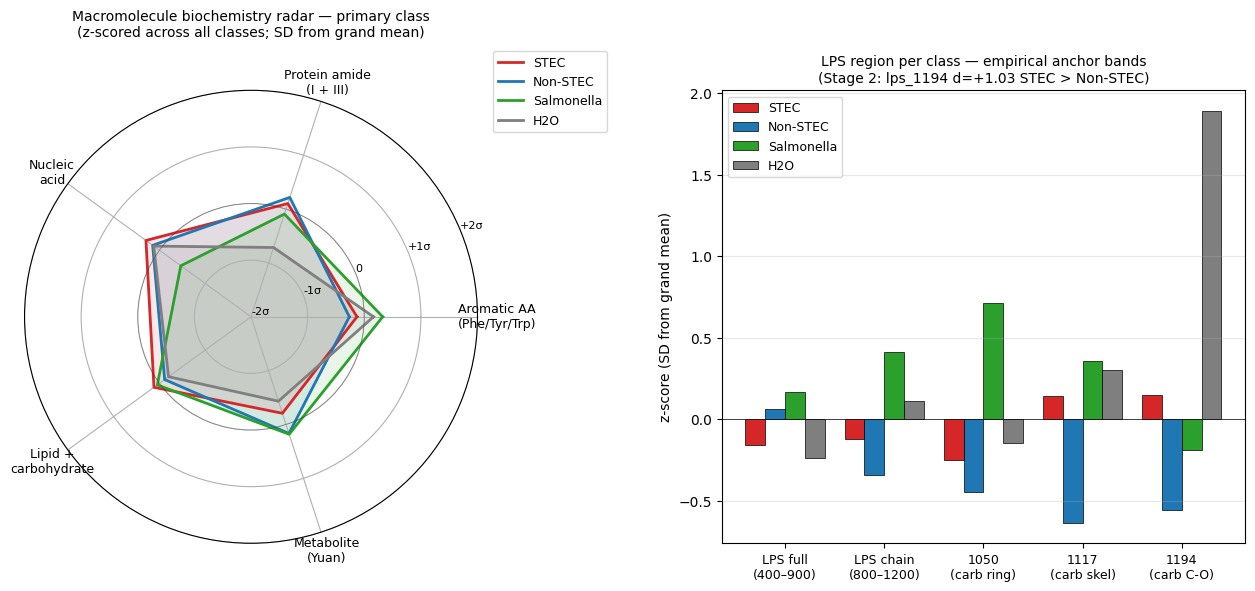

In [3]:
# ---------- D1: Per-class macromolecule radar ----------

GROUP_COLS = ["auc_aromatic_aa", "auc_protein_amide", "auc_nucleic_acid",
              "auc_lipid_carbohydrate", "auc_metabolite"]
GROUP_LABELS = ["Aromatic AA\n(Phe/Tyr/Trp)", "Protein amide\n(I + III)",
                "Nucleic\nacid", "Lipid +\ncarbohydrate",
                "Metabolite\n(Yuan)"]

# z-score each axis across all file-level rows
z_axes = (file_feat[GROUP_COLS] - file_feat[GROUP_COLS].mean()) / file_feat[GROUP_COLS].std()

# Class means on z-scored axes
class_z = z_axes.assign(pc=file_feat["primary_class"]).groupby("pc").mean()

# Radar plot
fig = plt.figure(figsize=(13, 6))

angles = np.linspace(0, 2 * np.pi, len(GROUP_COLS), endpoint=False).tolist()
angles += angles[:1]   # close

ax1 = fig.add_subplot(1, 2, 1, polar=True)
for c in CLASS_ORDER:
    if c not in class_z.index:
        continue
    vals = class_z.loc[c, GROUP_COLS].tolist()
    vals += vals[:1]
    ax1.plot(angles, vals, color=CLASS_COLORS[c], lw=2, label=c)
    ax1.fill(angles, vals, color=CLASS_COLORS[c], alpha=0.10)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(GROUP_LABELS, fontsize=9)
ax1.set_title("Macromolecule biochemistry radar — primary class\n(z-scored across all classes; SD from grand mean)",
              fontsize=10, y=1.10)
ax1.axhline(0, color="black", lw=0.5, alpha=0.3)
ax1.set_yticks([-2, -1, 0, 1, 2])
ax1.set_yticklabels(["-2σ", "-1σ", "0", "+1σ", "+2σ"], fontsize=8)
ax1.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10), fontsize=9)

# ---------- D2: LPS chain region z-score per class ----------
# This is the headline panel — the LPS region is where the discrimination lives.
ax2 = fig.add_subplot(1, 2, 2)
LPS_COLS = ["auc_lps_o_antigen_full", "auc_lps_chain_discrim",
            "auc_lps_1050", "auc_lps_1117", "auc_lps_1194"]
LPS_LABELS = ["LPS full\n(400–900)", "LPS chain\n(800–1200)",
              "1050\n(carb ring)", "1117\n(carb skel)", "1194\n(carb C-O)"]
lps_z_axes = (file_feat[LPS_COLS] - file_feat[LPS_COLS].mean()) / file_feat[LPS_COLS].std()
class_lps_z = lps_z_axes.assign(pc=file_feat["primary_class"]).groupby("pc").mean()

x_pos = np.arange(len(LPS_COLS))
w = 0.20
for i, c in enumerate(CLASS_ORDER):
    if c not in class_lps_z.index:
        continue
    ax2.bar(x_pos + (i - 1.5) * w, class_lps_z.loc[c, LPS_COLS],
            width=w, color=CLASS_COLORS[c], label=c, edgecolor="black", lw=0.5)
ax2.axhline(0, color="black", lw=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(LPS_LABELS, fontsize=9)
ax2.set_ylabel("z-score (SD from grand mean)")
ax2.set_title("LPS region per class — empirical anchor bands\n(Stage 2: lps_1194 d=+1.03 STEC > Non-STEC)",
              fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUT / "05_macromolecule_radar.png", bbox_inches="tight")
plt.show()


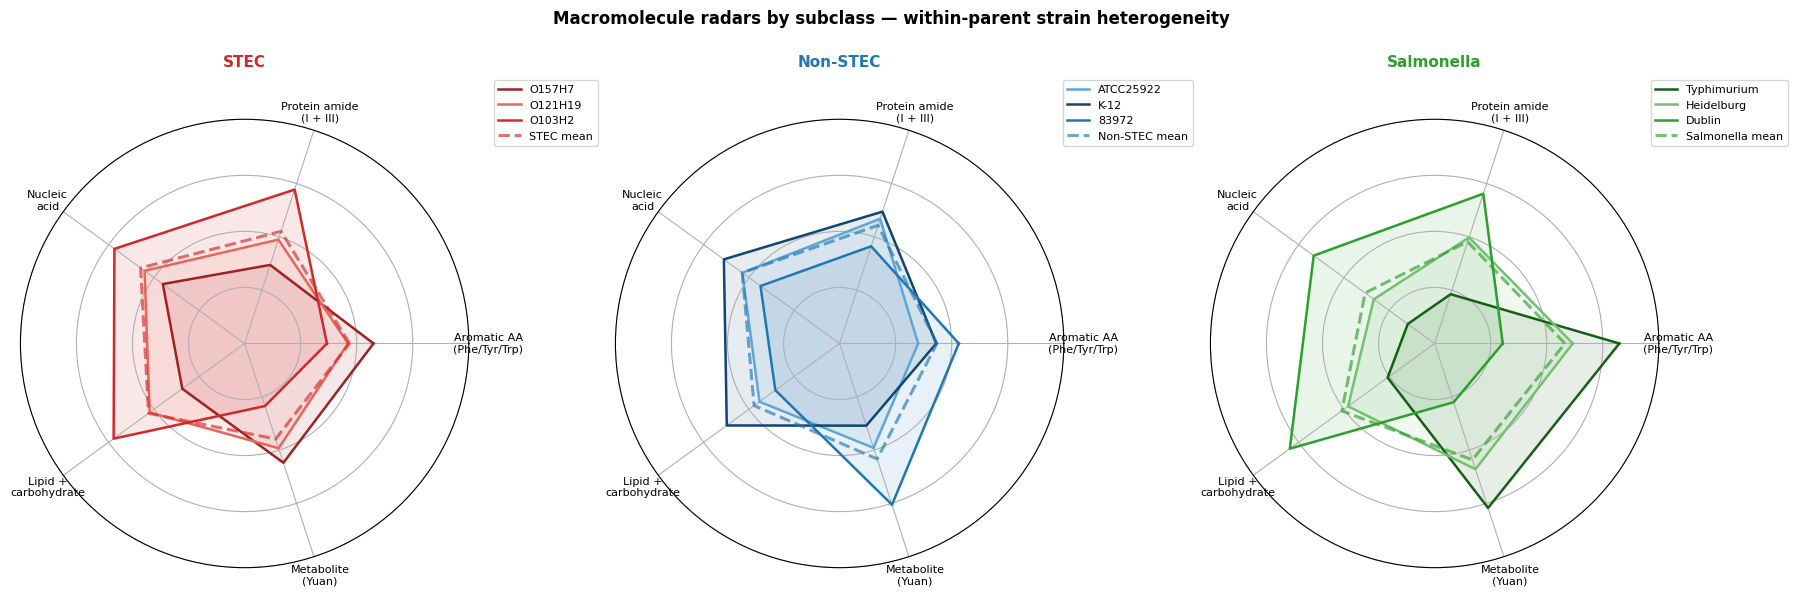

In [4]:
# ---------- D3: Per-subclass radar — within-parent strain comparison ----------

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

PARENT_SUBS = {
    "STEC":       ["O157H7", "O121H19", "O103H2"],
    "Non-STEC":   ["ATCC25922", "K-12", "83972"],
    "Salmonella": ["Typhimurium", "Heidelburg", "Dublin"],
}

# Subclass means on z-scored axes
sub_z = z_axes.assign(sc=file_feat["subclass"]).groupby("sc").mean()

for ax, (parent, subs) in zip(axes, PARENT_SUBS.items()):
    for s in subs:
        if s not in sub_z.index:
            continue
        vals = sub_z.loc[s, GROUP_COLS].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=SUBCLASS_COLORS[s], lw=1.8, label=s)
        ax.fill(angles, vals, color=SUBCLASS_COLORS[s], alpha=0.10)
    # Parent class mean (dashed)
    parent_vals = class_z.loc[parent, GROUP_COLS].tolist()
    parent_vals += parent_vals[:1]
    ax.plot(angles, parent_vals, color=CLASS_COLORS[parent], lw=2.2,
            ls="--", alpha=0.65, label=f"{parent} mean")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(GROUP_LABELS, fontsize=8)
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels([], fontsize=7)
    ax.set_title(parent, fontsize=11, fontweight="bold",
                 color=CLASS_COLORS[parent], y=1.10)
    ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.10), fontsize=8)

plt.suptitle("Macromolecule radars by subclass — within-parent strain heterogeneity",
             fontsize=12, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(OUT / "06_macromolecule_radar_subclass.png", bbox_inches="tight")
plt.show()


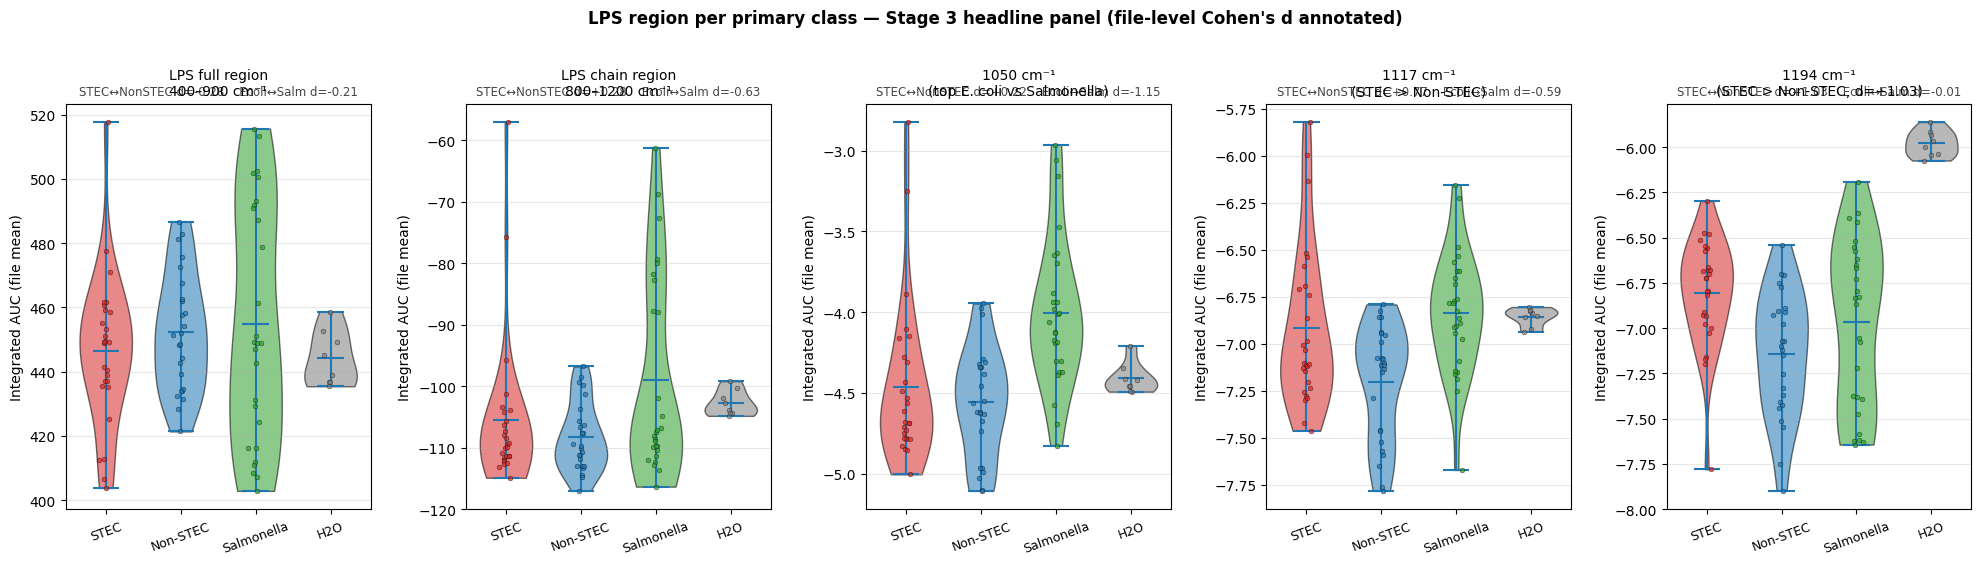

In [5]:
# ---------- D4: LPS region violins per primary class (headline plot) ----------

LPS_PLOT_BANDS = [
    ("auc_lps_o_antigen_full",  "LPS full region\n400–900 cm⁻¹"),
    ("auc_lps_chain_discrim",   "LPS chain region\n800–1200 cm⁻¹"),
    ("auc_lps_1050",            "1050 cm⁻¹\n(top E. coli vs Salmonella)"),
    ("auc_lps_1117",            "1117 cm⁻¹\n(STEC > Non-STEC)"),
    ("auc_lps_1194",            "1194 cm⁻¹\n(STEC > Non-STEC, d=+1.03)"),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5.5))
for ax, (col, label) in zip(axes, LPS_PLOT_BANDS):
    data = [file_feat.loc[file_feat["primary_class"] == c, col].dropna().values
            for c in CLASS_ORDER]
    parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                          showmeans=True, widths=0.7)
    for body, c in zip(parts["bodies"], CLASS_ORDER):
        body.set_facecolor(CLASS_COLORS[c])
        body.set_alpha(0.55)
        body.set_edgecolor("black")
    # Jittered strip on top
    for i, (c, vals) in enumerate(zip(CLASS_ORDER, data)):
        jitter = np.random.default_rng(i).normal(i, 0.04, size=len(vals))
        ax.scatter(jitter, vals, s=12, color=CLASS_COLORS[c],
                   edgecolor="black", lw=0.3, alpha=0.7, zorder=3)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, fontsize=9, rotation=20)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Integrated AUC (file mean)")
    ax.grid(alpha=0.3, axis="y")

    # Annotate STEC vs Non-STEC effect size
    a = file_feat.loc[file_feat["primary_class"] == "STEC", col].values
    b = file_feat.loc[file_feat["primary_class"] == "Non-STEC", col].values
    d = cohens_d(a, b)
    e = file_feat.loc[file_feat["primary_class"].isin(["STEC", "Non-STEC"]), col].values
    s = file_feat.loc[file_feat["primary_class"] == "Salmonella", col].values
    d_es = cohens_d(e, s)
    ax.text(0.5, 1.02,
            f"STEC↔NonSTEC d={d:+.2f}    Ecoli↔Salm d={d_es:+.2f}",
            transform=ax.transAxes, ha="center", fontsize=8.5, color="#444")

fig.suptitle("LPS region per primary class — Stage 3 headline panel "
             "(file-level Cohen's d annotated)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT / "07_lps_region_violins.png", bbox_inches="tight")
plt.show()


## §E — Band ratio analysis

Ratios cancel multiplicative file-level offsets, making them more robust to
acquisition-batch effects. The 10 default ratios are defined in
`atlas.band_features.DEFAULT_RATIOS` (plan/14 §5.1):

| Ratio | Numerator / Denominator | Type |
|---|---|---|
| `amide_over_na`            | protein_amide / nucleic_acid             | within-protein composition |
| `aa_over_amide`            | aromatic_aa / protein_amide              | within-protein composition |
| `lipid_over_protein`       | lipid_carb / protein_amide               | energy partitioning |
| `na_over_lipid`            | nucleic_acid / lipid_carb                | energy partitioning |
| `lps_chain_over_protein`   | LPS 800–1200 / protein_amide             | E. coli vs Salmonella anchor |
| `lps_1117_over_1050`       | 1117 / 1050                              | empirical anchor |
| `lps_1194_over_1050`       | 1194 / 1050                              | empirical anchor |
| `amide_1658_over_na_1338`  | 1658 / 1338                              | Cisek-style (literature) |
| `phe_1004_over_amide_1658` | 1004 / 1658                              | literature supporting |
| `na_786_over_phe_1004`     | 786 / 1004                               | literature supporting |

Ratios to plot: 10


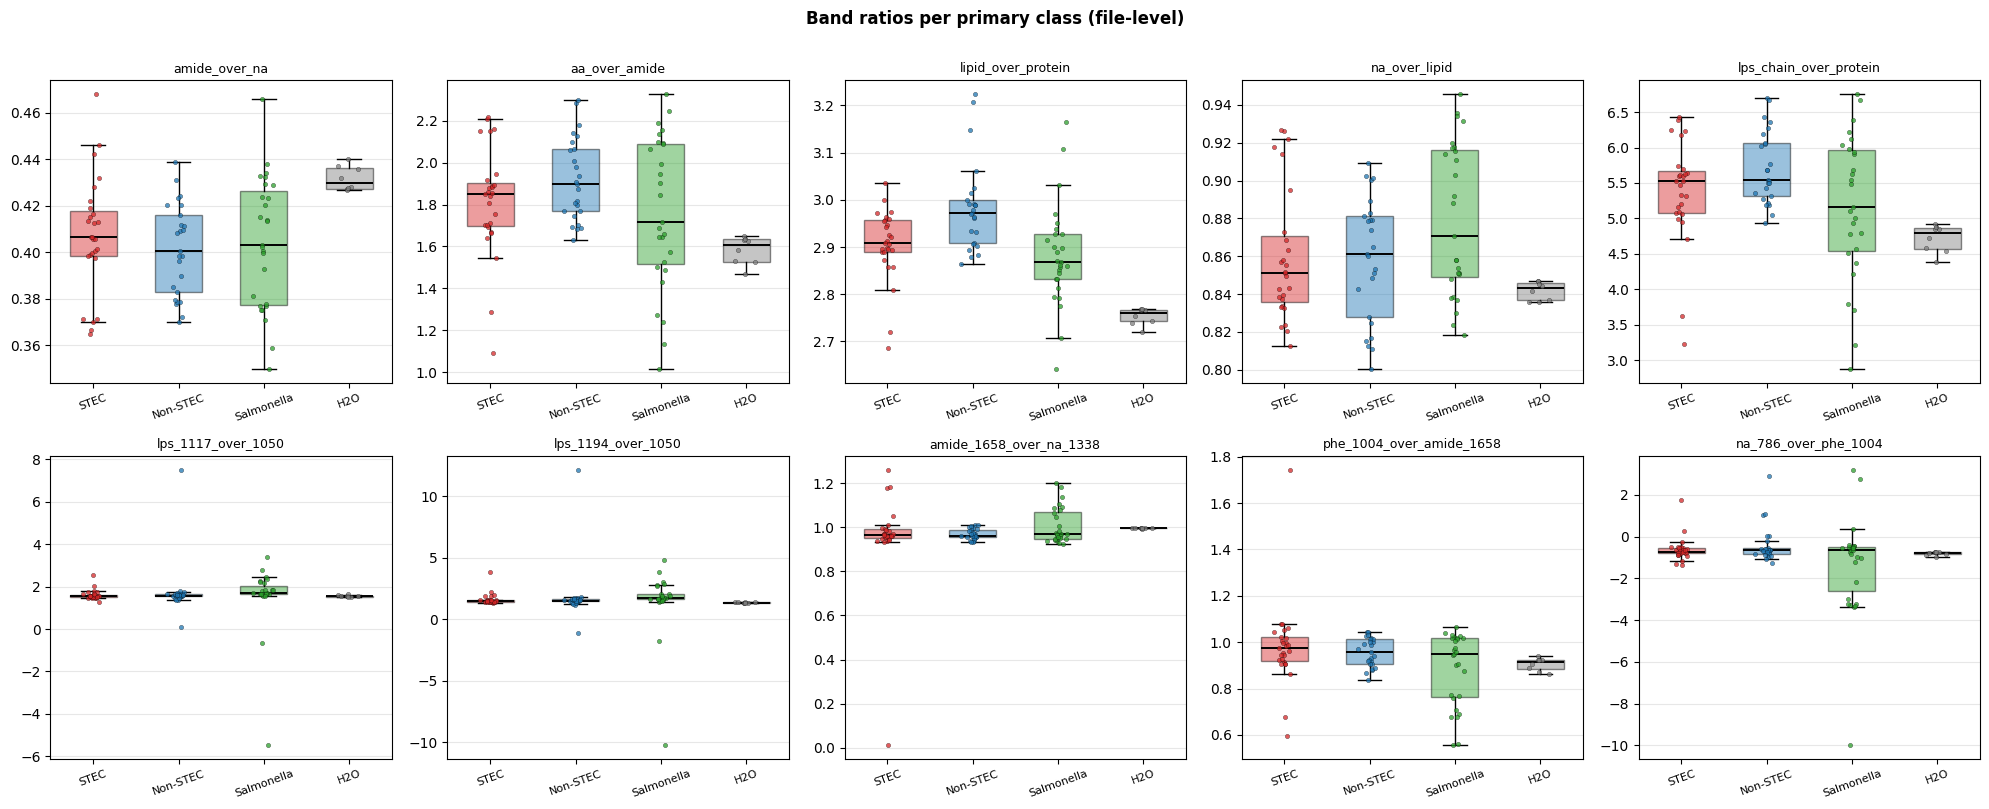

In [6]:
# ---------- E1: All ratios per class — boxplot grid ----------

ratio_cols = [c for c in file_feat.columns if c.startswith("ratio_")]
print(f"Ratios to plot: {len(ratio_cols)}")

n = len(ratio_cols)
ncols = 5
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flat

for ax, col in zip(axes, ratio_cols):
    data = [file_feat.loc[file_feat["primary_class"] == c, col].dropna().values
            for c in CLASS_ORDER]
    bp = ax.boxplot(data, positions=range(len(CLASS_ORDER)),
                    widths=0.55, patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", lw=1.4))
    for box, c in zip(bp["boxes"], CLASS_ORDER):
        box.set_facecolor(CLASS_COLORS[c]); box.set_alpha(0.45)
    for i, (c, vals) in enumerate(zip(CLASS_ORDER, data)):
        jitter = np.random.default_rng(i).normal(i, 0.05, size=len(vals))
        ax.scatter(jitter, vals, s=10, color=CLASS_COLORS[c],
                   edgecolor="black", lw=0.25, alpha=0.75, zorder=3)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels(CLASS_ORDER, fontsize=8, rotation=20)
    ax.set_title(col.replace("ratio_", ""), fontsize=9)
    ax.grid(alpha=0.3, axis="y")
for ax in axes[len(ratio_cols):]:
    ax.set_visible(False)

fig.suptitle("Band ratios per primary class (file-level)",
             fontsize=12, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(OUT / "08_band_ratios_per_class.png", bbox_inches="tight")
plt.show()


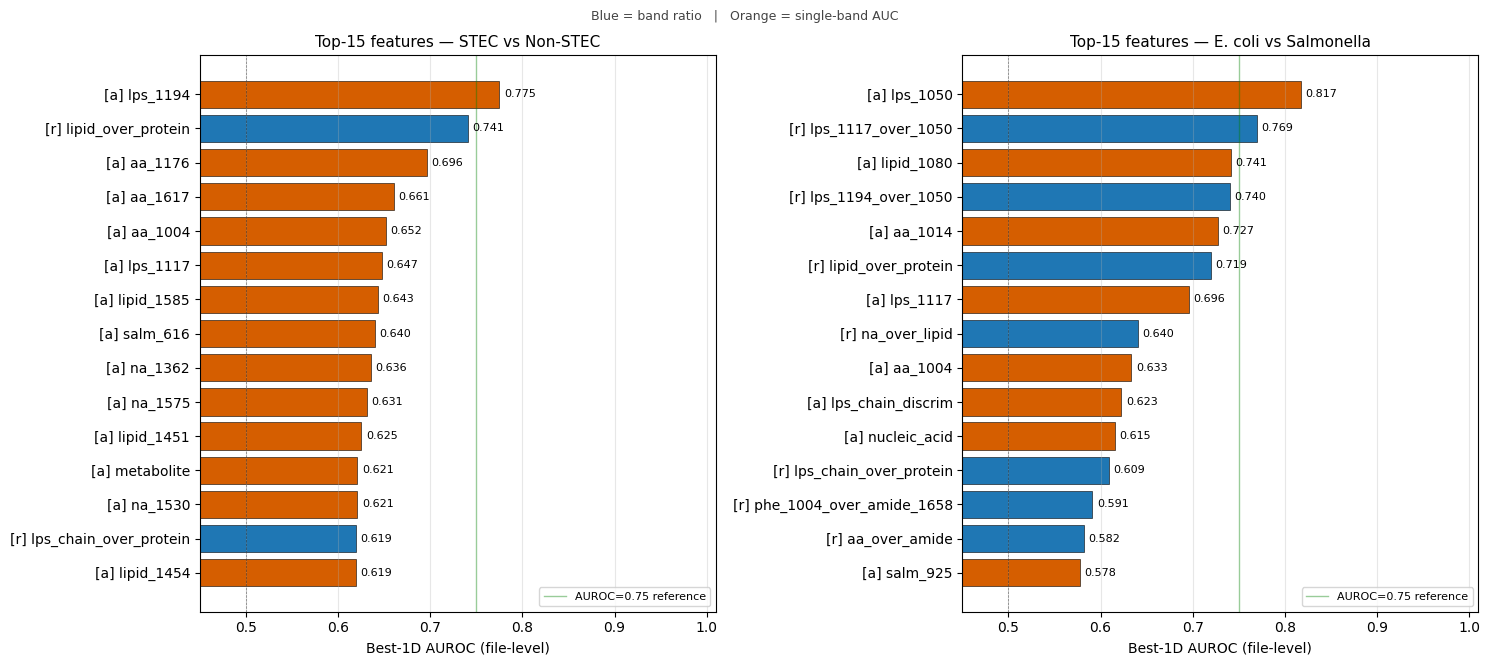

=== Best 1-D STEC vs Non-STEC (file-level) ===
  0.775  auc_lps_1194
  0.741  ratio_lipid_over_protein
  0.696  auc_aa_1176
  0.661  auc_aa_1617
  0.652  auc_aa_1004
\n=== Best 1-D E. coli vs Salmonella (file-level) ===
  0.817  auc_lps_1050
  0.769  ratio_lps_1117_over_1050
  0.741  auc_lipid_1080
  0.740  ratio_lps_1194_over_1050
  0.727  auc_aa_1014


In [7]:
# ---------- E2: Best-1D AUROC ranking ----------

def best_auroc(file_feat, col, positive_class, negative_classes):
    pos_mask = file_feat["primary_class"] == positive_class
    neg_mask = file_feat["primary_class"].isin(negative_classes)
    vals_pos = file_feat.loc[pos_mask, col].values
    vals_neg = file_feat.loc[neg_mask, col].values
    if len(vals_pos) < 2 or len(vals_neg) < 2:
        return np.nan
    y = np.r_[np.ones(len(vals_pos)), np.zeros(len(vals_neg))]
    s = np.r_[vals_pos, vals_neg]
    if not np.all(np.isfinite(s)):
        return np.nan
    auc = roc_auc_score(y, s)
    return max(auc, 1 - auc)   # symmetric

ratio_auroc_stec = {col: best_auroc(file_feat, col, "STEC", ["Non-STEC"])
                    for col in ratio_cols}
ratio_auroc_ecoli_salm = {col: best_auroc(
    file_feat.assign(primary_class=file_feat["primary_class"].replace(
        {"STEC": "Ecoli", "Non-STEC": "Ecoli"})), col, "Ecoli", ["Salmonella"]
) for col in ratio_cols}

# Also rank the raw band AUCs
band_cols = [c for c in file_feat.columns
             if c.startswith("auc_") and not c.startswith("auc_lps_o_antigen")]
band_auroc_stec = {col: best_auroc(file_feat, col, "STEC", ["Non-STEC"])
                   for col in band_cols}
band_auroc_ecoli_salm = {col: best_auroc(
    file_feat.assign(primary_class=file_feat["primary_class"].replace(
        {"STEC": "Ecoli", "Non-STEC": "Ecoli"})), col, "Ecoli", ["Salmonella"]
) for col in band_cols}

# Combine
all_features = {**ratio_auroc_stec, **band_auroc_stec}
all_features_es = {**ratio_auroc_ecoli_salm, **band_auroc_ecoli_salm}

top_stec = sorted(all_features.items(), key=lambda kv: -kv[1])[:15]
top_es   = sorted(all_features_es.items(), key=lambda kv: -kv[1])[:15]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, top, title in zip(axes,
                          [top_stec, top_es],
                          ["STEC vs Non-STEC", "E. coli vs Salmonella"]):
    names = [t[0].replace("ratio_", "[r] ").replace("auc_", "[a] ") for t in top]
    vals = [t[1] for t in top]
    colors = ["#1f77b4" if "[r]" in n else "#d55e00" for n in names]
    bars = ax.barh(names[::-1], vals[::-1], color=colors[::-1], edgecolor="black", lw=0.4)
    ax.axvline(0.5, color="black", lw=0.5, ls="--", alpha=0.5)
    ax.axvline(0.75, color="green", lw=1, alpha=0.4, label="AUROC=0.75 reference")
    ax.set_xlim(0.45, 1.01)
    ax.set_xlabel("Best-1D AUROC (file-level)")
    ax.set_title(f"Top-15 features — {title}", fontsize=11)
    for v, name in zip(vals[::-1], names[::-1]):
        ax.text(v + 0.005, name, f"{v:.3f}", va="center", fontsize=8)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3, axis="x")

# Legend for color coding
fig.text(0.5, 1.00,
         "Blue = band ratio   |   Orange = single-band AUC",
         ha="center", fontsize=9, color="#444")
plt.tight_layout()
plt.savefig(OUT / "09_best1d_auroc.png", bbox_inches="tight")
plt.show()

# Print headline numbers
print("=== Best 1-D STEC vs Non-STEC (file-level) ===")
for name, v in top_stec[:5]:
    print(f"  {v:.3f}  {name}")
print("\\n=== Best 1-D E. coli vs Salmonella (file-level) ===")
for name, v in top_es[:5]:
    print(f"  {v:.3f}  {name}")


Top-2 ratios for STEC vs Non-STEC: ratio_lipid_over_protein (0.741), ratio_lps_chain_over_protein (0.619)


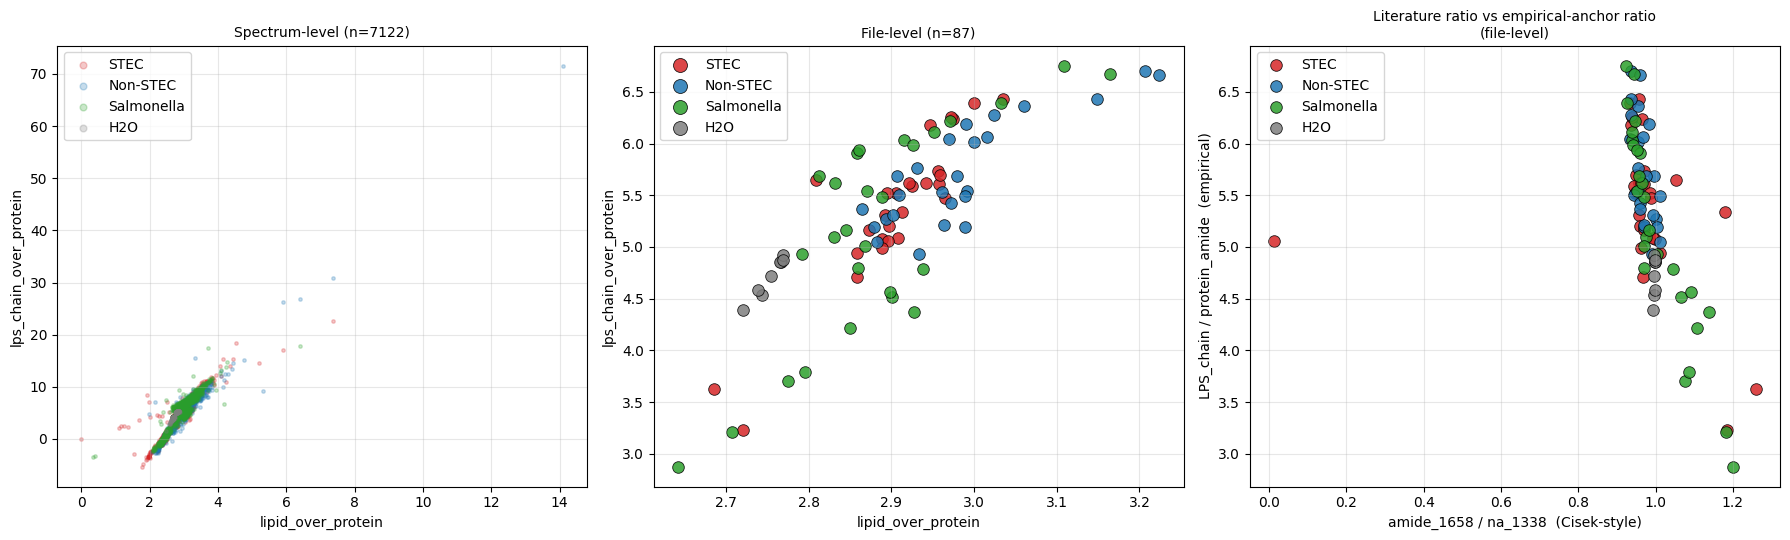

In [8]:
# ---------- E3: 2-D ratio scatter ----------
# Show the geometry of the two most-informative ratios for STEC vs Non-STEC.

# Pick the top-2 STEC-discriminating ratios for x/y
ratio_only_stec = [(k, v) for k, v in ratio_auroc_stec.items() if not np.isnan(v)]
ratio_only_stec.sort(key=lambda kv: -kv[1])
xr, yr = ratio_only_stec[0][0], ratio_only_stec[1][0]
print(f"Top-2 ratios for STEC vs Non-STEC: {xr} ({ratio_auroc_stec[xr]:.3f}), {yr} ({ratio_auroc_stec[yr]:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Spectrum-level scatter (small alpha)
ax = axes[0]
for c in CLASS_ORDER:
    m = feat["primary_class"] == c
    ax.scatter(feat.loc[m, xr], feat.loc[m, yr], s=6, alpha=0.25,
               color=CLASS_COLORS[c], label=c)
ax.set_xlabel(xr.replace("ratio_", "")); ax.set_ylabel(yr.replace("ratio_", ""))
ax.set_title(f"Spectrum-level (n={len(feat)})", fontsize=10)
ax.legend(markerscale=2)
ax.grid(alpha=0.3)

# File-level scatter
ax = axes[1]
for c in CLASS_ORDER:
    m = file_feat["primary_class"] == c
    ax.scatter(file_feat.loc[m, xr], file_feat.loc[m, yr], s=70,
               color=CLASS_COLORS[c], edgecolor="black", lw=0.6, label=c, alpha=0.85)
ax.set_xlabel(xr.replace("ratio_", "")); ax.set_ylabel(yr.replace("ratio_", ""))
ax.set_title(f"File-level (n={len(file_feat)})", fontsize=10)
ax.legend(markerscale=1.2)
ax.grid(alpha=0.3)

# Cisek-literature ratio: 1658/1338 (amide_1658_over_na_1338)
# vs empirical: lps_chain_over_protein
ax = axes[2]
cis_col = "ratio_amide_1658_over_na_1338"
emp_col = "ratio_lps_chain_over_protein"
for c in CLASS_ORDER:
    m = file_feat["primary_class"] == c
    ax.scatter(file_feat.loc[m, cis_col], file_feat.loc[m, emp_col], s=70,
               color=CLASS_COLORS[c], edgecolor="black", lw=0.6, label=c, alpha=0.85)
ax.set_xlabel("amide_1658 / na_1338  (Cisek-style)")
ax.set_ylabel("LPS_chain / protein_amide  (empirical)")
ax.set_title("Literature ratio vs empirical-anchor ratio\n(file-level)", fontsize=10)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "10_ratio_scatters.png", bbox_inches="tight")
plt.show()


## §F — Summary of Stage 3 findings

This section consolidates the numerical headlines from Sections D–E so the
notebook is self-contained.

In [9]:
# ---------- Summary table ----------

# Headline single-band AUROCs
headline_bands = ["auc_lps_1050", "auc_lps_1117", "auc_lps_1194",
                  "auc_lps_chain_discrim", "auc_lps_o_antigen_full",
                  "auc_na_1338", "auc_lipid_1454", "auc_amide_i_1658"]

rows = []
for col in headline_bands:
    if col not in file_feat.columns:
        continue
    a = file_feat.loc[file_feat["primary_class"] == "STEC", col].values
    b = file_feat.loc[file_feat["primary_class"] == "Non-STEC", col].values
    e = file_feat.loc[file_feat["primary_class"].isin(["STEC", "Non-STEC"]), col].values
    s = file_feat.loc[file_feat["primary_class"] == "Salmonella", col].values
    rows.append({
        "feature": col.replace("auc_", ""),
        "d_STEC_vs_NonSTEC": round(cohens_d(a, b), 3),
        "AUROC_STEC_vs_NonSTEC": round(best_auroc(file_feat, col, "STEC", ["Non-STEC"]), 3),
        "d_Ecoli_vs_Salm": round(cohens_d(e, s), 3),
        "AUROC_Ecoli_vs_Salm": round(
            best_auroc(file_feat.assign(
                primary_class=file_feat["primary_class"].replace(
                    {"STEC": "Ecoli", "Non-STEC": "Ecoli"})),
                col, "Ecoli", ["Salmonella"]), 3),
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(OUT / "11_stage3_summary.csv", index=False)
print(f"\\nwrote {OUT / '11_stage3_summary.csv'}")


           feature  d_STEC_vs_NonSTEC  AUROC_STEC_vs_NonSTEC  d_Ecoli_vs_Salm  AUROC_Ecoli_vs_Salm
          lps_1050              0.217                  0.501           -1.147                0.817
          lps_1117              0.766                  0.647           -0.585                0.696
          lps_1194              1.032                  0.775           -0.005                0.515
 lps_chain_discrim              0.278                  0.532           -0.634                0.623
lps_o_antigen_full             -0.275                  0.566           -0.210                0.516
           na_1338              0.129                  0.526            0.047                0.524
        lipid_1454             -0.470                  0.619            0.075                0.526
      amide_i_1658             -0.074                  0.517            0.332                0.550
\nwrote /Users/devashishthapliyal/Documents/NomadX/outputs/band_chemistry/11_stage3_summary.csv


### Verdict against plan/08 Stage 3 pre-registration

Pre-registration locked in plan/08 (2026-05-17 Stage 3 entry):

1. **Salmonella LPS axis ≥ 1 z-SD above E. coli classes on LPS chain region** → check the LPS bar chart in §D (panel 2).
2. **STEC and Non-STEC overlap on protein_amide / NA / aromatic_aa axes** → check the macromolecule radar in §D (panel 1) — the two classes should sit on top of each other on those 3 axes.
3. **Best-1D ratio AUROC for STEC vs Non-STEC ≥ 0.80** → check `09_best1d_auroc.png` left panel.
4. **Best-1D ratio for STEC vs Non-STEC contains lps_1117 or lps_1194** → check feature name in §E2.
5. **Best-1D ratio AUROC for E. coli vs Salmonella ≥ 0.75** → check `09_best1d_auroc.png` right panel.
6. **Cisek-style ratio `amide_1658 / na_1338` AUROC for STEC vs Non-STEC < 0.65** → check rank in §E2.

Verdicts get appended to plan/07 and plan/08 by `scripts/build_band_features_cache.py` or via a follow-up commit.